Choose Mode:
1 → Image Detection
2 → Video Detection

0: 448x640 1 car, 50.8ms
Speed: 19.0ms preprocess, 50.8ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


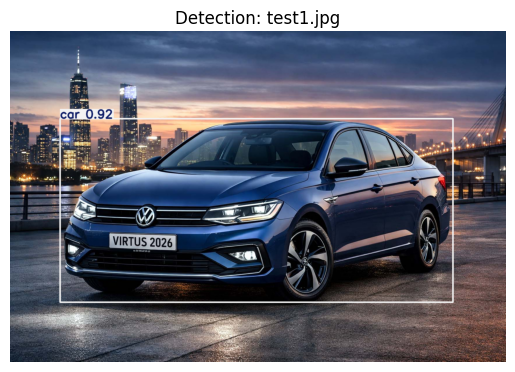

Saved: output_test1.jpg

0: 384x640 1 car, 39.0ms
Speed: 2.1ms preprocess, 39.0ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)


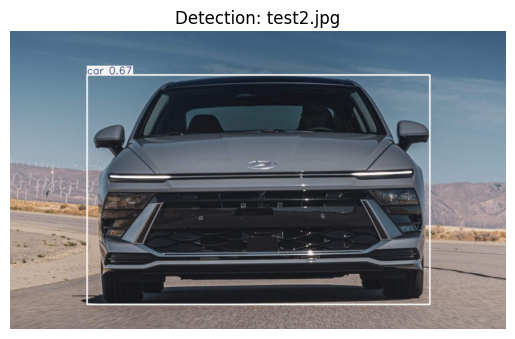

Saved: output_test2.jpg


In [1]:
# ---------------- VEHICLE DETECTION (FINAL CLEAN VERSION) ----------------

from ultralytics import YOLO
import cv2
import os
from matplotlib import pyplot as plt

# Load YOLOv8 pretrained model
model = YOLO("yolov8n.pt")


# ---------------- IMAGE DETECTION ----------------
def detect_images(folder="images"):
    if not os.path.exists(folder):
        print(f"Folder '{folder}' not found")
        return

    for file in os.listdir(folder):
        if file.endswith((".jpg", ".png", ".jpeg")):
            path = os.path.join(folder, file)

            img = cv2.imread(path)
            results = model(img)

            for r in results:
                output = r.plot()

            # Show image (Notebook-friendly)
            plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
            plt.title(f"Detection: {file}")
            plt.axis("off")
            plt.show()

            # Save output
            output_path = f"output_{file}"
            cv2.imwrite(output_path, output)
            print(f"Saved: {output_path}")


# ---------------- VIDEO DETECTION ----------------
def detect_video(video_path="test.mp4"):
    if not os.path.exists(video_path):
        print("Video file not found")
        return

    cap = cv2.VideoCapture(video_path)

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame)

        for r in results:
            output = r.plot()

        # Convert and display in notebook
        plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
        plt.title("Video Frame Detection")
        plt.axis("off")
        plt.show()

        break  # show only first frame (avoid spam)


# ---------------- RUN ----------------
print("Choose Mode:")
print("1 → Image Detection")
print("2 → Video Detection")

choice = input("Enter choice (1/2): ")

if choice == "1":
    detect_images("images")
elif choice == "2":
    detect_video("test.mp4")
else:
    print("Invalid choice")